# Cuaderno extra: Recuperación y preprocesamiento de imágenes propias

Este cuaderno está pensado para trabajar con una imagen tomada por vos, por ejemplo una captura hecha a partir de la cámara oscura construida con caja de zapatos y bolsa. La idea es recuperar información útil antes de segmentar: mejorar contraste, corregir brillo, recortar la zona importante y reducir ruido.

## Objetivos

- Cargar una imagen propia y describirla.
- Detectar qué problema visual conviene corregir primero.
- Aplicar una o dos operaciones de preprocesamiento con criterio.
- Comparar la imagen original con la versión mejorada.
- Guardar una imagen lista para usar en la actividad integradora.


## Antes de empezar

No todas las imágenes necesitan el mismo tratamiento. En algunas puede convenir mejorar el contraste. En otras, recortar la zona útil. En otras, reducir ruido o corregir una dominante de iluminación.

La pregunta importante no es "qué filtro aplico", sino "qué problema veo en la imagen y qué operación puede ayudarme a resolverlo".


In [3]:
#Este bloque prepara todo el entorno para trabajar con tus imágenes pequeno - 1 y pequeno - 3: 
# carga archivos, muestra imágenes, compara resultados y define funciones de preprocesamiento 
# como brillo, suavizado, mejora de contraste e histograma.

# Permite trabajar con rutas y nombres de archivos de forma más ordenada.
from pathlib import Path

# OpenCV: lectura, conversión y procesamiento de imágenes.
import cv2

# Matplotlib: visualización de imágenes y gráficos.
import matplotlib.pyplot as plt

# NumPy: operaciones numéricas y cálculo de histogramas.
import numpy as np


# Carga una imagen desde disco y la convierte de BGR a RGB.
def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))

    # Si la imagen no se puede abrir, muestra un error claro.
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo abrir la imagen: {ruta}")

    # Convierte la imagen al orden RGB para visualizarla correctamente.
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


# Muestra una imagen con un título.
# Si la imagen es de un solo canal, la muestra en escala de grises.
def mostrar_imagen(imagen, titulo="Imagen"):
    plt.figure(figsize=(6, 6))
    plt.imshow(imagen, cmap="gray" if imagen.ndim == 2 else None)
    plt.title(titulo)
    plt.axis("off")
    plt.show()


# Muestra lado a lado una imagen original y una procesada para compararlas visualmente.
def mostrar_comparacion(original, procesada, titulo_original="Original", titulo_procesada="Procesada"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(original, cmap="gray" if original.ndim == 2 else None)
    axes[0].set_title(titulo_original)
    axes[0].axis("off")

    axes[1].imshow(procesada, cmap="gray" if procesada.ndim == 2 else None)
    axes[1].set_title(titulo_procesada)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# Ajusta brillo y contraste de la imagen.
# alpha controla el contraste y beta el brillo.
def ajustar_brillo_contraste(imagen_rgb, alpha=1.2, beta=10):
    return cv2.convertScaleAbs(imagen_rgb, alpha=alpha, beta=beta)


# Aplica un desenfoque gaussiano para suavizar la imagen y reducir ruido.
def suavizar(imagen_rgb, kernel=5):
    return cv2.GaussianBlur(imagen_rgb, (kernel, kernel), 0)


# Mejora el contraste local usando CLAHE sobre el canal de luminancia.
def mejorar_contraste_clahe(imagen_rgb, clip_limit=2.0, tile=8):
    # Convertir la imagen al espacio LAB para trabajar sobre la luminancia.
    imagen_lab = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2LAB)

    # Separar los canales L, A y B.
    l, a, b = cv2.split(imagen_lab)

    # Crear el objeto CLAHE con los parámetros elegidos.
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile, tile))

    # Mejorar solo el canal de luz para evitar distorsionar los colores.
    l_mejorado = clahe.apply(l)

    # Volver a unir los canales y regresar a RGB.
    imagen_lab_mejorada = cv2.merge((l_mejorado, a, b))
    return cv2.cvtColor(imagen_lab_mejorada, cv2.COLOR_LAB2RGB)


# Calcula y muestra el histograma de la imagen en escala de grises.
def mostrar_histograma_gris(imagen_rgb):
    # Convertir la imagen color a escala de grises.
    gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)

    # Calcular la distribución de intensidades.
    hist, bins = np.histogram(gris.flatten(), bins=256, range=[0, 256])

    # Graficar el histograma.
    plt.figure(figsize=(10, 4))
    plt.plot(bins[:-1], hist, color="black")
    plt.title("Histograma en escala de grises")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()

    #La idea general del bloque es:
    # dejar listas herramientas reutilizables para probar distintos preprocesamientos 
    # sobre mis imágenes propias sin escribir el mismo código una y otra vez.


## Parte 1. Cargá tu imagen

Guardá tu archivo en la misma carpeta del notebook o escribí la ruta completa. Si tu imagen viene de la experiencia con cámara oscura, conviene elegir una captura donde todavía se reconozca bien la escena, aunque tenga poco contraste o zonas oscuras.


Archivo cargado: Pequeno - 1.jpeg
Forma: (251, 408, 3)
Tipo de dato: uint8


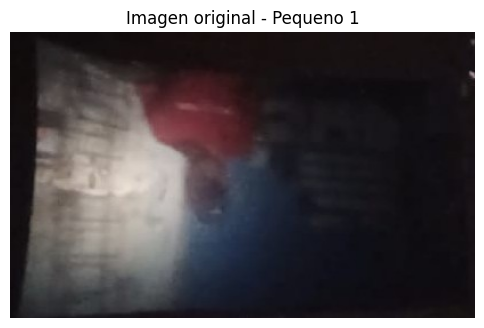

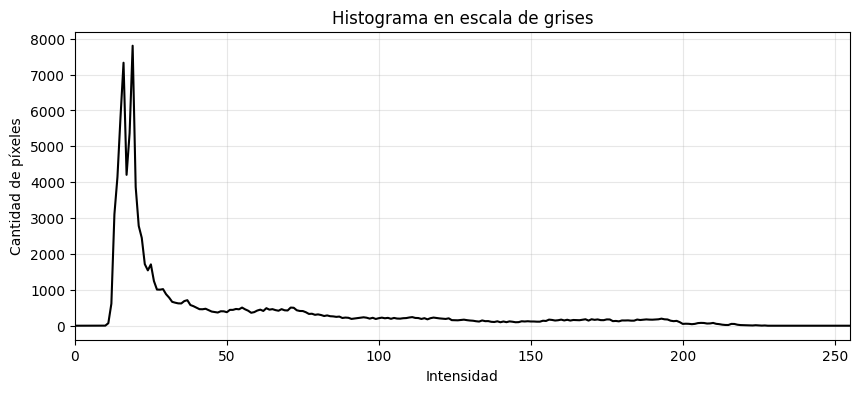

In [5]:
# Definir el nombre del archivo de imagen con el que vamos a trabajar.
nombre_imagen = "Pequeno - 1.jpeg"
ruta = Path(nombre_imagen)

# Cargar la imagen en formato RGB.
imagen_original = cargar_rgb(ruta)

# Mostrar información básica del archivo cargado.
print(f"Archivo cargado: {ruta}")
print(f"Forma: {imagen_original.shape}")
print(f"Tipo de dato: {imagen_original.dtype}")

# Mostrar la imagen original para observar su estado inicial.
mostrar_imagen(imagen_original, "Imagen original - Pequeno 1")

# Mostrar el histograma en escala de grises para analizar la distribución de intensidades.
mostrar_histograma_gris(imagen_original)



## Parte 2. Diagnóstico inicial

Escribí qué problema principal ves en la imagen. 

*Está subexpuesta o muy oscura en gran parte de la escena.

*Tiene contraste desigual: hay una zona muy iluminada a la izquierda y mucho oscurecimiento en el resto.

*Presenta desenfoque o falta de nitidez, porque los detalles no se distinguen claramente.

*Parece haber ruido o grano, sobre todo en las zonas oscuras.

*La iluminación no es uniforme, lo que dificulta recuperar detalles de toda la imagen.

*También podría haber un leve velo o baja claridad general, como si la imagen estuviera capturada con poca luz o a través de una superficie.


In [6]:
# Identificar el problema principal observado en la imagen.
problema_principal = "La imagen presenta muy poca iluminación y una distribución desigual de la luz, con gran parte de la escena demasiado oscura."

# Plantear una primera hipótesis de mejora para recuperar visibilidad.
hipotesis_mejora = "Voy a probar primero un ajuste de brillo y contraste para intentar resaltar las zonas oscuras y hacer más visibles los detalles."

print("Problema principal:", problema_principal)
print("Operación que voy a probar primero:", hipotesis_mejora)


Problema principal: La imagen presenta muy poca iluminación y una distribución desigual de la luz, con gran parte de la escena demasiado oscura.
Operación que voy a probar primero: Voy a probar primero un ajuste de brillo y contraste para intentar resaltar las zonas oscuras y hacer más visibles los detalles.


## Parte 3. Recorte opcional de la zona útil

Si la imagen tiene mucho fondo innecesario, podés recortar la región más importante antes de mejorarla. Si no necesitás recorte, dejá la imagen completa.


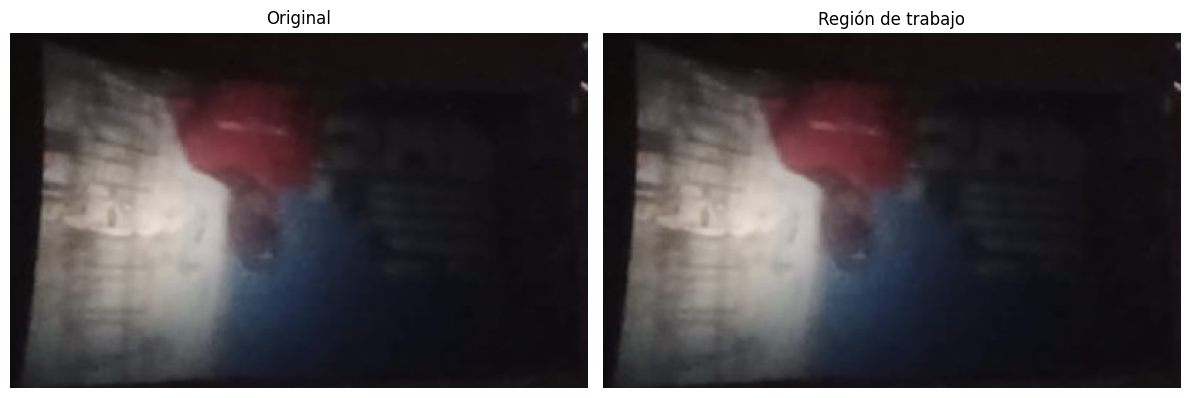

In [8]:
# En este caso se usa la imagen completa como región de trabajo.
# No se recorta porque primero conviene analizar la iluminación general de toda la escena.
y1, y2 = 0, imagen_original.shape[0]
x1, x2 = 0, imagen_original.shape[1]

# Extraer la región de trabajo.
imagen_recortada = imagen_original[y1:y2, x1:x2]

# Comparar la imagen original con la región seleccionada.
mostrar_comparacion(imagen_original, imagen_recortada, "Original", "Región de trabajo")


# Se decidió no recortar la imagen en esta etapa, ya que el problema de iluminación afecta a casi toda la escena
# y conviene evaluar primero una mejora global antes de focalizar en una región específica.


## Parte 4. Probá mejoras de preprocesamiento

Acá tenés tres operaciones posibles. No hace falta usar todas. La idea es que pruebes, compares y decidas cuál te sirve más para preparar la imagen.


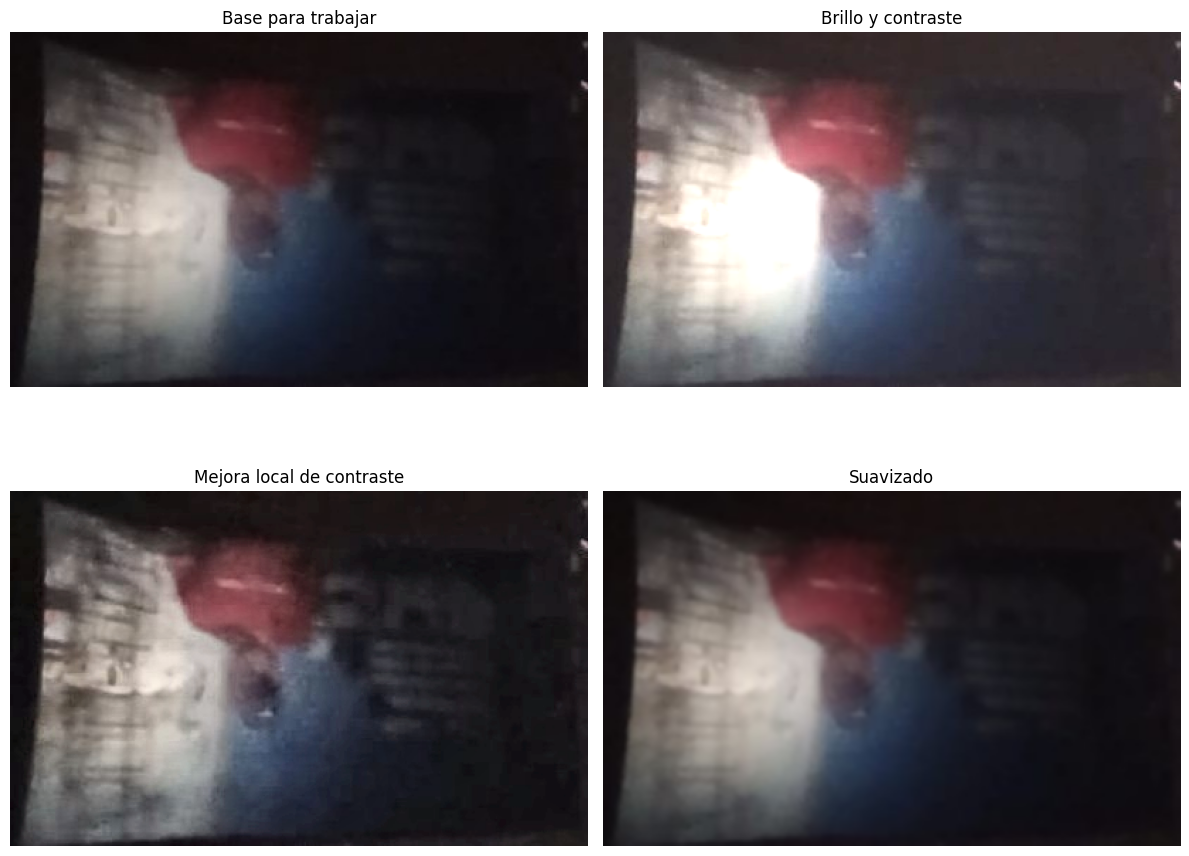

In [ ]:
# Aplicar un ajuste global de brillo y contraste para intentar aclarar la imagen.
brillo_contraste = ajustar_brillo_contraste(imagen_recortada, alpha=1.4, beta=20)

# Aplicar CLAHE para mejorar el contraste local y resaltar detalles en distintas zonas.
clahe = mejorar_contraste_clahe(imagen_recortada, clip_limit=2.0, tile=8)

# Aplicar un suavizado gaussiano para reducir ruido y pequeñas variaciones.
suavizada = suavizar(imagen_recortada, kernel=5)

# Crear una figura para comparar la imagen base con las tres versiones procesadas.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Mostrar la imagen original que se usará como referencia.
axes[0, 0].imshow(imagen_recortada)
axes[0, 0].set_title("Base para trabajar")
axes[0, 0].axis("off")

# Mostrar la versión con brillo y contraste ajustados.
axes[0, 1].imshow(brillo_contraste)
axes[0, 1].set_title("Brillo y contraste")
axes[0, 1].axis("off")

# Mostrar la versión con mejora local de contraste.
axes[1, 0].imshow(clahe)
axes[1, 0].set_title("Mejora local de contraste")
axes[1, 0].axis("off")

# Mostrar la versión suavizada.
axes[1, 1].imshow(suavizada)
axes[1, 1].set_title("Suavizado")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# En esta comparación, las operaciones más útiles para una imagen oscura suelen ser
# el ajuste de brillo/contraste y la mejora local de contraste, mientras que el suavizado
# ayuda más a reducir ruido que a recuperar visibilidad.

# La operación que ofrece el resultado más útil es la mejora local de contraste,
# ya que permite recuperar mejor los detalles en una imagen con iluminación desigual.
# El ajuste global de brillo y contraste sobreexpone la zona más iluminada,
# y el suavizado no mejora suficientemente la visibilidad general.




De esas tres, la que parece dar mejores resultados es mejora local de contraste (CLAHE).


Brillo y contraste: aclara la imagen, pero quema mucho la zona luminosa de la izquierda eso hace perder detalle en esa parte 

Suavizado: reduce un poco el ruido, pero no mejora realmente la visibilidad
la imagen sigue demasiado oscura y además más borrosa 

Mejora local de contraste: recupera mejor los detalles en distintas zonas no sobreexpone tanto como el ajuste global mantiene un equilibrio más útil entre claridad y estructura 

Entonces, para esta imagen, la mejor opción inicial sería CLAHE, porque mejora la lectura visual sin deteriorar tanto las zonas claras.

## Parte 5. Elegí una versión final

Elegí cuál de las variantes te conviene conservar como imagen preprocesada. Si querés, también podés combinar operaciones en dos pasos, por ejemplo: primero mejorar contraste y después suavizar.


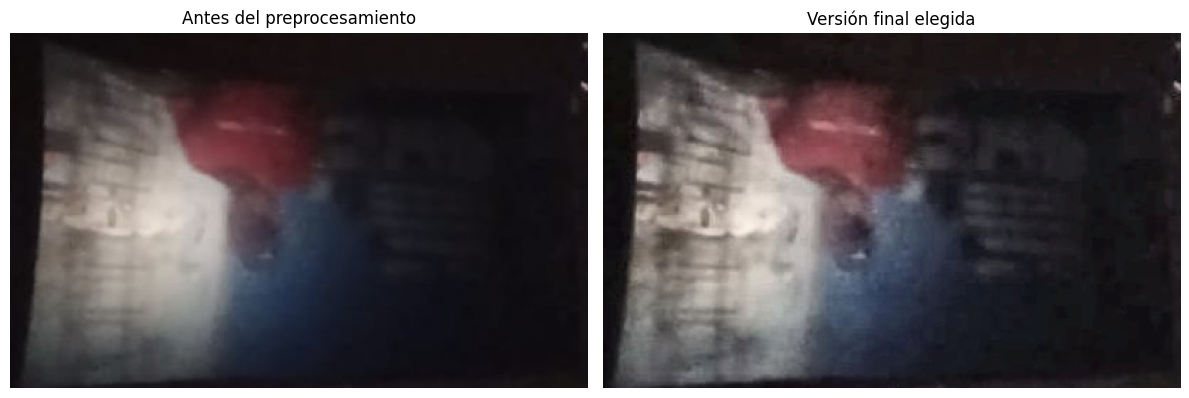

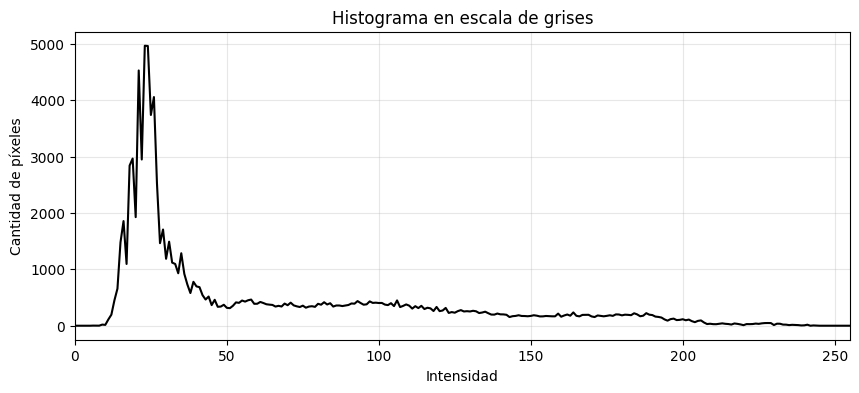

In [ ]:
# Elegir como resultado final la versión con mejora local de contraste,
# porque fue la que ofreció mejor recuperación visual sin sobreexponer tanto la imagen.
imagen_preprocesada = clahe

# Ejemplo de combinación posible si más adelante se quiere probar una estrategia mixta.
# imagen_preprocesada = suavizar(ajustar_brillo_contraste(imagen_recortada, alpha=1.3, beta=15), kernel=5)

# Comparar la imagen antes y después del preprocesamiento elegido.
mostrar_comparacion(imagen_recortada, imagen_preprocesada, "Antes del preprocesamiento", "Versión final elegida")

# Mostrar el histograma de la imagen preprocesada para analizar cómo cambió la distribución de intensidades.
mostrar_histograma_gris(imagen_preprocesada)

# Se eligió la mejora local de contraste como preprocesamiento final,
# ya que permitió recuperar mejor los detalles en una imagen con iluminación desigual.
# La comparación visual y el histograma ayudan a justificar esta elección.

# El preprocesamiento mejoró parcialmente la visibilidad de la imagen y permitió recuperar
# algunos detalles en las zonas oscuras. Sin embargo, la escena sigue presentando poca luz
# y falta de nitidez, por lo que la mejora fue útil pero no suficiente para corregir por completo la imagen.



Visualmente se observa que:

la versión final elegida recupera algo más de detalle en las zonas oscuras
el contraste local mejoró, especialmente en áreas donde antes casi no se distinguía nada. aun así, la imagen sigue siendo bastante oscura y borrosa
no aparece una recuperación total de nitidez, porque el preprocesamiento mejora la visibilidad, pero no puede reconstruir información que no fue capturada con claridad 


Sobre el histograma:
la mayor concentración de píxeles sigue estando en intensidades bajas
eso confirma que la imagen continúa dominada por tonos oscuros
sin embargo, también hay una distribución más extendida hacia intensidades medias
eso sugiere que el contraste mejoró y que ahora algunos detalles ocupan un rango tonal más amplio

En conclusión: el CLAHE fue útil para hacer más visible la información presente en la imagen, sobre todo en zonas oscuras, pero la mejora es limitada porque el problema original no era solo de contraste, sino también de baja iluminación y falta de nitidez.


## Parte 6. Guardá el resultado para la actividad integradora

El objetivo es que el próximo cuaderno pueda tomar esta imagen como punto de partida.


In [ ]:
#La idea del bloque es: 
# conservar una copia del mejor resultado obtenido para usarla después, 
# compararla o incluirla en la entrega.

# Definir el nombre del archivo de salida para guardar la imagen preprocesada.
salida = Path("imagen_preprocesada.png")

# Guardar la imagen en disco.
# Se convierte de RGB a BGR porque OpenCV guarda las imágenes en ese formato.
cv2.imwrite(str(salida), cv2.cvtColor(imagen_preprocesada, cv2.COLOR_RGB2BGR))

# Mostrar la ruta completa donde quedó almacenado el archivo.
print(f"Imagen guardada en: {salida.resolve()}")



Imagen guardada en: C:\Users\carme\OneDrive\Documents\Procesamiento de imágenes\rodriguez-carmen-pdi-1c-2026\003 - librerias_fundamentos_pdi\LABORATORIO\imagen_preprocesada.png


## Cierre escrito

Respondé con tus palabras:

1. ¿Qué problema principal tenía la imagen original?
    La imagen original tenía poca iluminación, bajo contraste y escasa nitidez.
2. ¿Qué operación u operaciones usaste para mejorarla?
    Para mejorarla usé CLAHE, una técnica de mejora local de contraste.
3. ¿Qué cambió entre la imagen original y la preprocesada?
    La imagen preprocesada mostró más detalle en zonas oscuras y una mejor distribución de intensidades, aunque no recuperó completamente la nitidez.
4. ¿Por qué pensás que esta nueva versión puede servir mejor para segmentar?
    Esta versión puede servir mejor para segmentar porque diferencia mejor algunas regiones y hace más visibles ciertos detalles que antes quedaban ocultos.




### Siguiente paso

Usá `imagen_preprocesada.png` en `008 - actividad integradora - segmentacion por color.ipynb` como imagen de entrada principal.